In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

# Carichiamo il preprocessing
with open("preprocessing.pkl", "rb") as f:
    prep = pickle.load(f)

X_train = prep["X_train"]
print(f"X_train shape: {X_train.shape}")

X_train shape: (202, 6)


Bandwidth ottimale: 0.2069


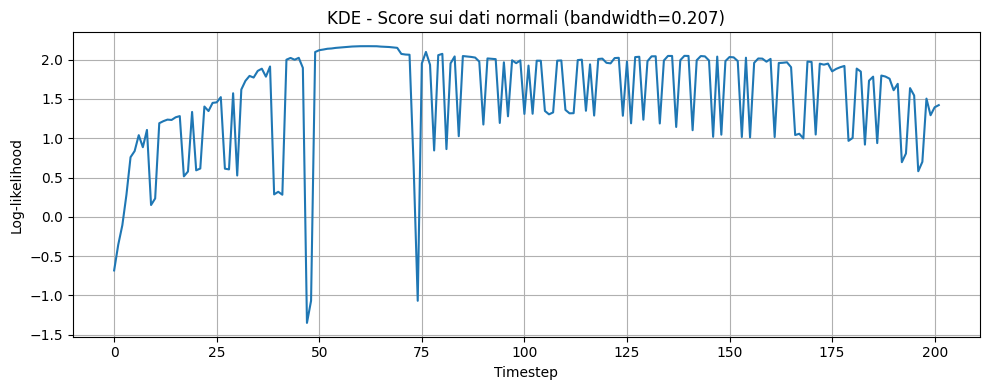

Score medio: 1.545
Score min:   -1.348
Score max:   2.170


In [3]:
from sklearn.model_selection import GridSearchCV

bandwidths = np.logspace(-1, 1, 20)
grid = GridSearchCV(
    KernelDensity(kernel="gaussian"),
    param_grid={"bandwidth": bandwidths},
    cv=5
)
grid.fit(X_train)

best_bw = grid.best_params_["bandwidth"]
print(f"Bandwidth ottimale: {best_bw:.4f}")

# Riaddestariamo con il bandwidth ottimale
kde = KernelDensity(kernel="gaussian", bandwidth=best_bw)
kde.fit(X_train)

scores_train = kde.score_samples(X_train)

plt.figure(figsize=(10, 4))
plt.plot(scores_train)
plt.xlabel("Timestep")
plt.ylabel("Log-likelihood")
plt.title(f"KDE - Score sui dati normali (bandwidth={best_bw:.3f})")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Score medio: {scores_train.mean():.3f}")
print(f"Score min:   {scores_train.min():.3f}")
print(f"Score max:   {scores_train.max():.3f}")

Soglia (percentile 5): 0.287


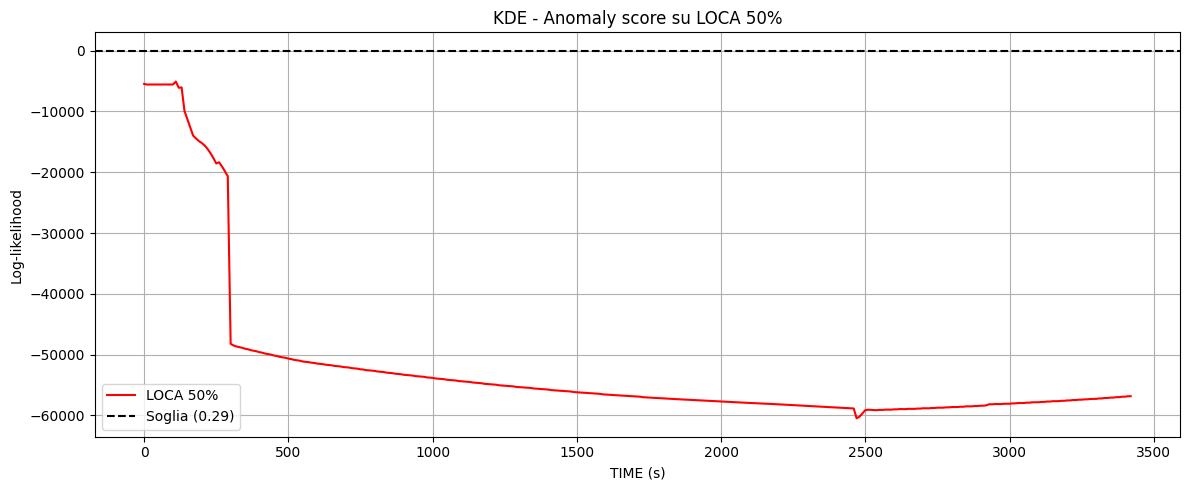

Timestep anomali rilevati: 343/343 (100.0%)


In [5]:
# Soglia: percentile 5 degli score normali
threshold = np.percentile(scores_train, 5)
print(f"Soglia (percentile 5): {threshold:.3f}")

# Testiamo su un LOCA
import pandas as pd
import os

DATA_PATH = "NuclearPowerPlantAccidentData/Operation_csv_data"

def compute_anomaly_score(df, prep, kde):
    """Trasforma un dataframe e calcola gli score KDE"""
    X = df[prep["features_kept"]].values
    X_scaled = prep["scaler"].transform(X)
    X_pca = prep["pca"].transform(X_scaled)
    scores = kde.score_samples(X_pca)
    return scores

# Carichiamo LOCA severità 50
df_loca = pd.read_csv(os.path.join(DATA_PATH, "LOCA", "50.csv"))
scores_loca = compute_anomaly_score(df_loca, prep, kde)

# Visualizziamo
plt.figure(figsize=(12, 5))
plt.plot(df_loca["TIME"], scores_loca, color="red", label="LOCA 50%")
plt.axhline(y=threshold, color="black", linestyle="--", label=f"Soglia ({threshold:.2f})")
plt.xlabel("TIME (s)")
plt.ylabel("Log-likelihood")
plt.title("KDE - Anomaly score su LOCA 50%")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Quanti timestep rilevati come anomalia?
n_anomaly = (scores_loca < threshold).sum()
print(f"Timestep anomali rilevati: {n_anomaly}/{len(scores_loca)} ({100*n_anomaly/len(scores_loca):.1f}%)")

In [7]:
conditions = sorted(os.listdir(DATA_PATH))

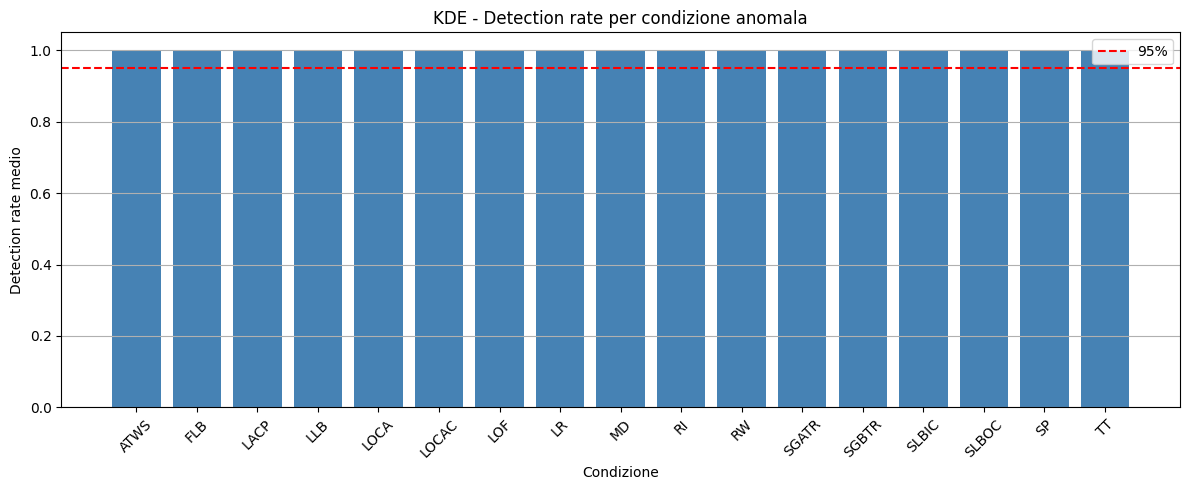

ATWS       100.0%
FLB        100.0%
LACP       100.0%
LLB        100.0%
LOCA       100.0%
LOCAC      100.0%
LOF        100.0%
LR         100.0%
MD         100.0%
RI         100.0%
RW         100.0%
SGATR      100.0%
SGBTR      100.0%
SLBIC      100.0%
SLBOC      100.0%
SP         100.0%
TT         100.0%


In [8]:
# Test su tutte le condizioni
results = {}

for cond in conditions:
    if cond == "Normal":
        continue
    
    cond_path = os.path.join(DATA_PATH, cond)
    files = os.listdir(cond_path)
    
    detected = []
    for f in files:
        df = pd.read_csv(os.path.join(cond_path, f))
        scores = compute_anomaly_score(df, prep, kde)
        # Detection rate: % di timestep rilevati come anomalia
        rate = (scores < threshold).mean()
        detected.append(rate)
    
    results[cond] = np.mean(detected)

# Visualizziamo
plt.figure(figsize=(12, 5))
plt.bar(results.keys(), results.values(), color="steelblue")
plt.axhline(y=0.95, color="red", linestyle="--", label="95%")
plt.xlabel("Condizione")
plt.ylabel("Detection rate medio")
plt.title("KDE - Detection rate per condizione anomala")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

for cond, rate in results.items():
    print(f"{cond:<10} {rate*100:.1f}%")

In [10]:
df_normal = pd.read_csv(os.path.join(DATA_PATH, "Normal", "1.csv"))
# False positive rate sui dati normali
scores_normal_all = kde.score_samples(
    prep["pca"].transform(
        prep["scaler"].transform(df_normal[prep["features_kept"]].values)
    )
)

fp_rate = (scores_normal_all < threshold).mean()
print(f"False positive rate (dati normali completi): {fp_rate*100:.1f}%")

# E sul solo training set (steady state)
fp_rate_train = (scores_train < threshold).mean()
print(f"False positive rate (steady state): {fp_rate_train*100:.1f}%")

False positive rate (dati normali completi): 36.8%
False positive rate (steady state): 5.4%


In [11]:
import pickle

# Aggiungiamo il modello al file di preprocessing
prep["kde"] = kde
prep["threshold"] = threshold

with open("preprocessing.pkl", "wb") as f:
    pickle.dump(prep, f)

print("Modello KDE salvato!")

Modello KDE salvato!
